# Micrograd Implementation – Gradient Intuition
This notebook follows the ideas from the Micrograd tutorial by Andrej Karpathy.
The goal is to understand how gradients work and how neural networks compute derivatives
before building a full automatic differentiation engine.
We begin with simple functions and approximate derivatives using numerical methods.

## Import Required Libraries
We import the libraries needed for numerical computation and visualization.

In [1]:
##Learning Gradient descent optimization, making an function then differentiate it and take slope of that 
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Defining a Mathematical Function

We start with a simple mathematical function.
This will help us understand how the slope (gradient) behaves at different points.

In [2]:
def f(x):
    return (2*x**2+7)/3
f(4)

13.0

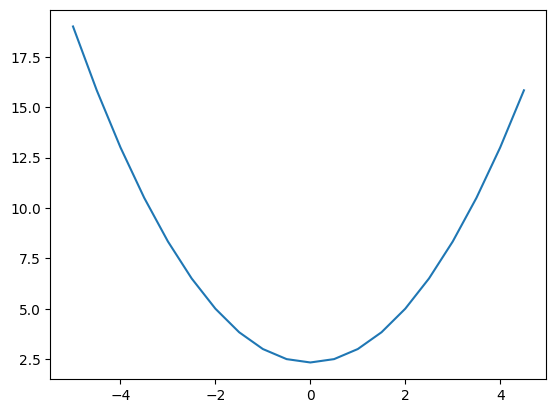

In [3]:
x = np.arange(-5,5,0.5)
y = f(x)
plt.plot(x,y)

In [4]:
f(-2)

5.0

## Numerical Derivative (Finite Difference)
Before automatic differentiation, we approximate derivatives using the finite difference method.
Derivative approximation formula:
f'(x) ≈ (f(x + h) − f(x)) / h
Where:
h = small step size

In [5]:
h = 0.02000001
x = 2/3
(f(x+h)-f(x))/h

0.9022222288888834

In [6]:
##checking for slope
h = 0.001
#inputs
a = 10
b = 8
c = 22

d1 = a*b +c
c+=h
d2 = a*b +c
print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)


d1 102
d2 102.001
slope 1.0000000000047748


## Visualizing the Function
Plotting the function helps us understand the relationship between the input and output.
It also helps visualize where the gradient is computed.

In [7]:
class Value:
    def __init__(self, data, _children=(), _op='', label= ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __neg__(self):
            return self*(-1)
    def __sub__(self,other):
        return self + (-other)
    def __rmul__(self,other):
        return self * other

    def __truediv__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1
    def __pow__(self, other):
        assert isinstance (other, (int,float))
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1))*out.grad
        out._backward = _backward
        return out
            
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,),'exp')
        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
    def relu(self):
        out = Value(self.data if self.data > 0 else 0,(self,), 'RELU')
        def _backward():
            self.grad += (1.0 if self.data >0 else 0.0)
        out._backward = _backward
        return out
    def tanh(self):
        n = self.data
        t = math.tanh(self.data)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward
        return out
    def backward(self):
        nodes = []
        visited = set()
        def build_nodes(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_nodes(child)
                nodes.append(v)
        build_nodes(self)
        self.grad = 1.0
        for node in reversed(nodes):
                node._backward()


In [8]:
#!pip install graphviz
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [9]:
def deri():
    h = 0.01
    a = Value(2.0, label='a')
    b = Value(30.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e - c; d.label = 'd'
    f = Value(-4.0, label= 'f')
    L = d + f; L.label = 'L'
    L1 = L.data


    a = Value(2.0+h, label='a')
    b = Value(30.0 , label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e - c; d.label = 'd'
    f = Value(-4.0, label= 'f')
    L = d + f; L.label = 'L'
    L2 = L.data
        
    print((L2-L1)/h)
deri()
    
    

29.999999999999716


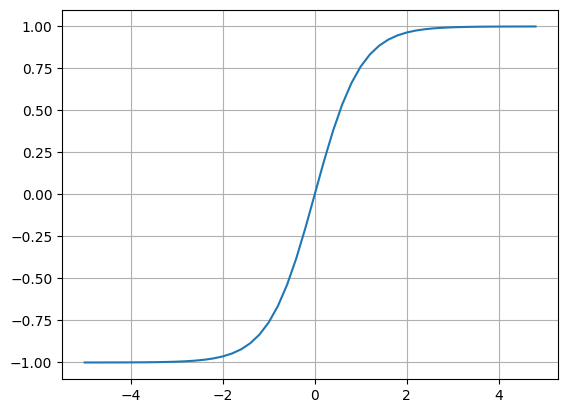

In [10]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [11]:
#inputs, weights, bias of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(4.0, label='x2')
w1 = Value(5.0, label='w1')
w2 = Value(7.0, label='w2')
g = Value(9.0, label='g')
x1w1 = x1*w1; x1w1.label= 'x1w1'
x2w2 = x2*w2; x2w2.label= 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + g; n.label = 'n'
p = n.tanh();p.label = 'p'
#p.grad = 1.0            # activation function gradient should be 1#
#n.grad = 0.66036
#x1w1x2w2.grad = 0.66036
#g.grad = 0.66036
#x2w2.grad = 0.66036
#x1w1.grad = 0.66036
#x1.grad +=w1.data * x1w1.grad
#w1.grad +=x1.data * x1w1.grad
#w2.grad +=x2.data * x2w2.grad
#x2.grad +=w2.data * x2w2.grad
p.backward()




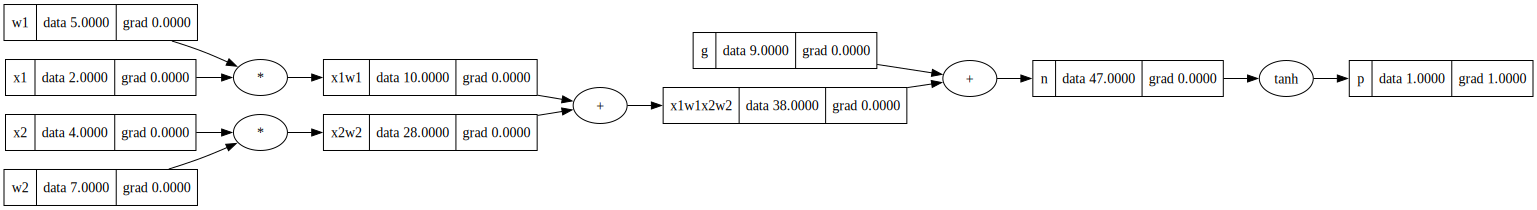

In [12]:
draw_dot(p)

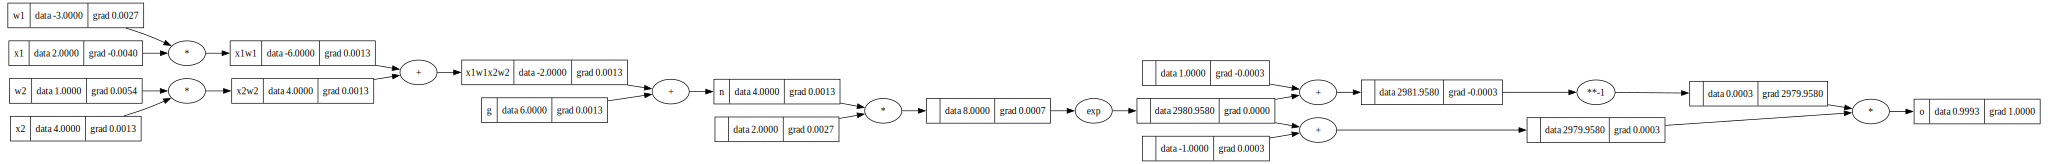

In [13]:
#inputs, weights, bias of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(4.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
g = Value(6.0, label='g')
x1w1 = x1*w1; x1w1.label= 'x1w1'
x2w2 = x2*w2; x2w2.label= 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + g; n.label = 'n'
#p.grad = 1.0            # activation function gradient should be 1#
##forward pass : compute funtion value##
##backward pass : differentiation of function##
e = (2*n).exp()
o = (e-1)/(e+1)
o.label = 'o'
o.backward()
draw_dot(o)


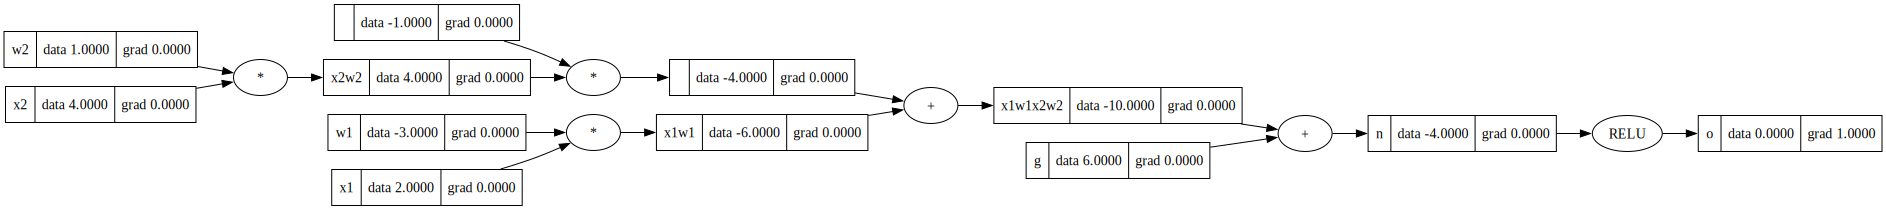

In [14]:
#inputs, weights, bias of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(4.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
g = Value(6.0, label='g')
x1w1 = x1*w1; x1w1.label= 'x1w1'
x2w2 = x2*w2; x2w2.label= 'x2w2'
x1w1x2w2 = x1w1 - x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + g; n.label = 'n'
#p.grad = 1.0            # activation function gradient should be 1#
##forward pass : compute funtion value##
##backward pass : differentiation of function##
o = n.relu()
o.label = 'o'
o.backward()
draw_dot(o)



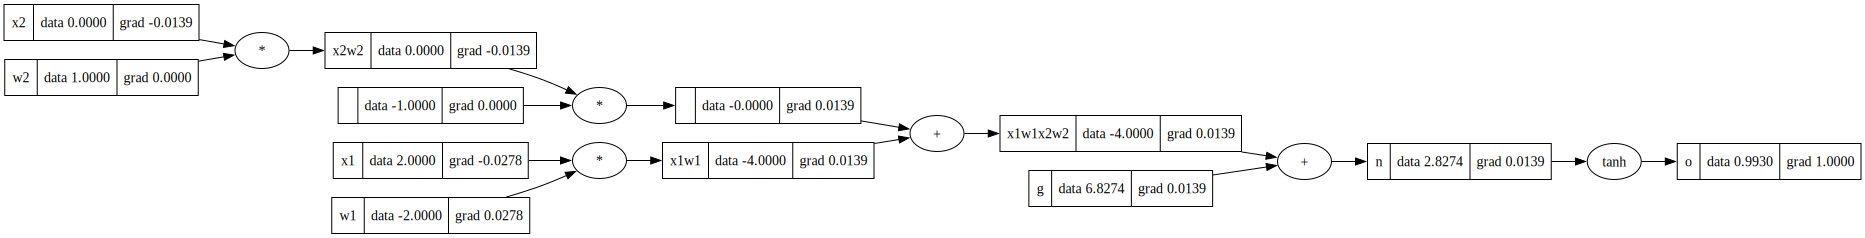

In [15]:
#inputs, weights, bias of the neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-2.0, label='w1')
w2 = Value(1.0, label='w2')
g = Value(6.8273827723883, label='g')
x1w1 = x1*w1; x1w1.label= 'x1w1'
x2w2 = x2*w2; x2w2.label= 'x2w2'
x1w1x2w2 = x1w1 - x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + g; n.label = 'n'
#p.grad = 1.0            # activation function gradient should be 1#
##forward pass : compute funtion value##
##backward pass : differentiation of function##
o = n.tanh()
o.label = 'o'
o.backward()
draw_dot(o)



In [16]:
####Now using PyTorch libraries####
import torch

In [17]:
x1 = torch.Tensor([2.0]).double() ;x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ;x2.requires_grad = True
w1 = torch.Tensor([-2.0]).double() ;w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ;w2.requires_grad = True
b = torch.Tensor([6.8273827723883]).double() ;b.requires_grad = True
fnc = x1*w1 + x2*w2 + b
p = torch.tanh(fnc)
print(p.data.item())
p.backward()
#print('x2', x2.grad.item())
#print('x1', x1.grad.item())
#print('w1', w1.grad.item())
#print('w2', w2.grad.item())


0.9930228351748699


In [205]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    def __call__(self,x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    def parameters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self, nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range (len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [335]:
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=0.4068917685777578)

In [336]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys = [1.0,-1.0,-1.0,1.0]

In [337]:
ypred = [n(x) for x in xs]
mseloss = sum(((b-a)**2 for a,b in zip(ys, ypred)),Value(0.0))
mseloss

Value(data=4.0542313583509015)

In [338]:
for k in range(10): 
    ypred = [n(x) for x in xs]
    loss = sum (((yout - ygt)**2 for ygt,yout in zip(ys,ypred)),Value(0.0))
    loss.backward()
    for p in n.parameters():
        p.data += -0.01 * p.grad
    print(k,loss.data)

0 4.0542313583509015
1 3.758511349082781
2 3.3968458435924727
3 3.3062624053118195
4 3.4073360504270327
5 3.256999551096537
6 2.55254054291102
7 1.5109264552149102
8 0.8154757027100058
9 0.4445795171258308


In [1]:
ypred

NameError: name 'ypred' is not defined